<a href="https://colab.research.google.com/github/mahi-builds/mahi-builds/blob/main/iothealth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install wfdb
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import os

print("Libraries installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 21.6 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
Libraries installed successfully!


In [2]:
import wfdb
import os

# Create data directory
if not os.path.exists('mit_afdb'):
    os.makedirs('mit_afdb')

# Solution: Download using the 'afdb' database name.
# Sometimes PhysioNet requires '04015' or similar names for the AFDB.
# Let's try record '04015' which is a standard AF record in this DB.
try:
    print("Attempting to download record 04015...")
    wfdb.dl_database('afdb', dl_dir='mit_afdb', records=['04015'])

    # Load the record and annotations
    record = wfdb.rdrecord('mit_afdb/04015')
    annotation = wfdb.rdann('mit_afdb/04015', 'atr')

    fs = record.fs
    print(f"\nSuccess!")
    print(f"Record Name: {record.record_name}")
    print(f"Sampling Frequency: {fs} Hz")

except Exception as e:
    print(f"\nError: {e}")
    print("If 404 persists, we will use the 'mitdb' (Arrhythmia DB) which is more stable for testing.")

Attempting to download record 04015...
Generating record list for: 04015
Generating list of all files for: 04015
Finished downloading files

Success!
Record Name: 04015
Sampling Frequency: 250 Hz


In [ ]:
# Extract the first channel (Lead II equivalent)
ecg_data = record.p_signal[:, 0]

# Define window size (10 seconds)
window_size = 2500

# Calculate how many full 10-second windows we can get
num_windows = len(ecg_data) // window_size
segments = ecg_data[:num_windows * window_size].reshape(-1, window_size)

print(f"Total 10-second segments extracted: {len(segments)}")

Total 10-second segments extracted: 3682


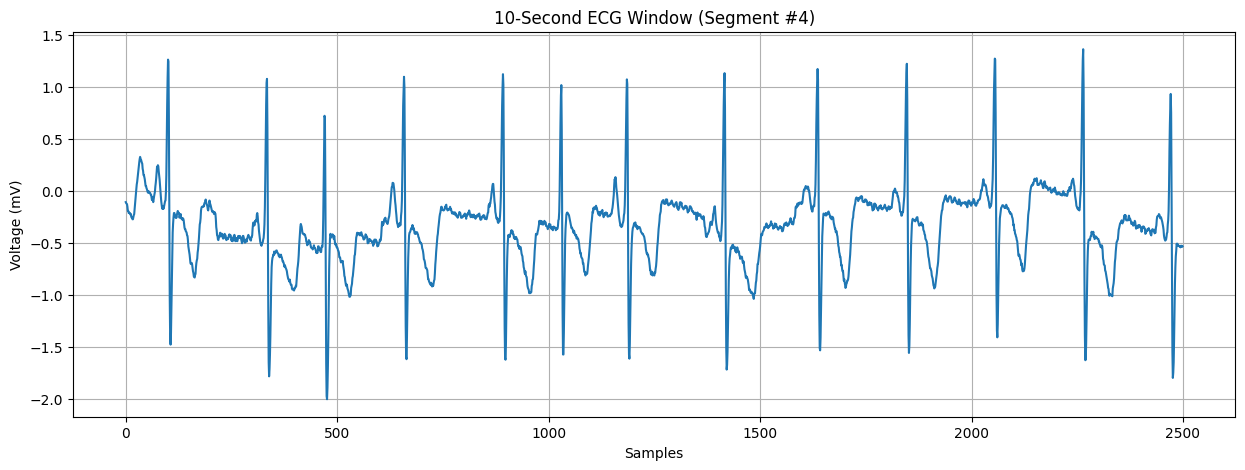

In [ ]:
plt.figure(figsize=(15, 5))
# Plotting the 5th segment (Index 4)
plt.plot(segments[4])
plt.title("10-Second ECG Window (Segment #4)")
plt.xlabel("Samples")
plt.ylabel("Voltage (mV)")
plt.grid(True)
plt.show()

In [ ]:
# Extract the sample indices and the labels from the annotation file
ann_samples = annotation.sample
ann_labels = annotation.aux_note

print(f"Annotations found: {ann_labels}")

# Function to get the label for a specific 10-second window
def get_window_label(start_sample, end_sample, ann_samples, ann_labels):
    current_label = 'N' # Default to Normal
    # Check what the label was at the start of this window
    for i in range(len(ann_samples)):
        if ann_samples[i] <= start_sample:
            # Clean the label string (remove parenthesis)
            clean_label = ann_labels[i].replace('(', '').strip()
            if clean_label == 'AFIB':
                current_label = 'AF'
            elif clean_label == 'N':
                current_label = 'N'
        else:
            break
    return current_label

# Label all our segments
labeled_data = []
for i in range(len(segments)):
    start_s = i * window_size
    end_s = start_s + window_size
    label = get_window_label(start_s, end_s, ann_samples, ann_labels)
    labeled_data.append(label)

# Check our distribution
from collections import Counter
print(f"\nWindow Distribution: {Counter(labeled_data)}")

Annotations found: ['(N', '(AFIB', '(N', '(AFIB', '(N', '(AFIB', '(N', '(AFIB', '(N', '(AFIB', '(N', '(AFIB', '(N', '(AFIB', '(N']

Window Distribution: Counter({'N': 3659, 'AF': 23})


Normalization Complete.


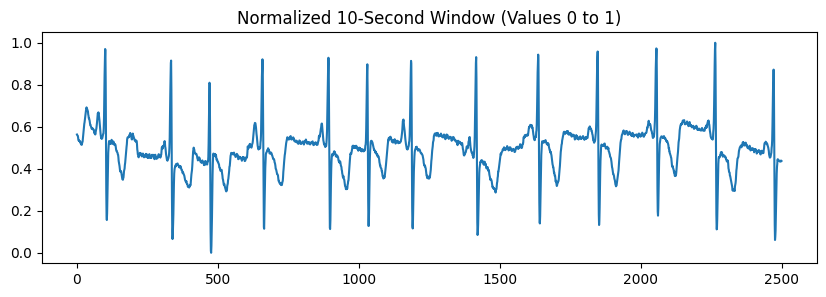

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

# Reshape, scale, and reshape back
segments_normalized = scaler.fit_transform(segments.T).T

print("Normalization Complete.")

# Verify: Plot a normalized segment
plt.figure(figsize=(10, 3))
plt.plot(segments_normalized[4])
plt.title("Normalized 10-Second Window (Values 0 to 1)")
plt.show()

In [ ]:
import numpy as np
import wfdb

# List of records from the AFDB to build a balanced dataset
# 04015, 04043, 04126, 04746 are standard records with mixed AF/Normal
records_to_get = ['04015', '04043', '04126', '04746']
all_segments = []
all_labels = []
window_size = 2500 # 10 seconds at 250Hz

for rec_id in records_to_get:
    print(f"Processing Record: {rec_id}...")

    # Download and read
    wfdb.dl_database('afdb', dl_dir='mit_afdb', records=[rec_id])
    rec = wfdb.rdrecord(f'mit_afdb/{rec_id}')
    ann = wfdb.rdann(f'mit_afdb/{rec_id}', 'atr')

    sig = rec.p_signal[:, 0]

    # Create windows
    num_w = len(sig) // window_size
    for i in range(num_w):
        start = i * window_size
        end = start + window_size

        # Get signal segment
        segment = sig[start:end]

        # Determine Label
        label = 'N'
        for j in range(len(ann.sample)):
            if ann.sample[j] <= start:
                clean_l = ann.aux_note[j].replace('(', '').strip()
                label = 'AF' if clean_l == 'AFIB' else 'N'
            else:
                break

        all_segments.append(segment)
        all_labels.append(1 if label == 'AF' else 0)

# Convert to Numpy Arrays
X = np.array(all_segments)
y = np.array(all_labels)

# Reshape X for the CNN (Samples, Time-steps, Channels)
X = X.reshape(X.shape[0], X.shape[1], 1)

print(f"\nFinal Dataset Shape: {X.shape}")
print(f"Total AF Windows: {sum(y)}")
print(f"Total Normal Windows: {len(y) - sum(y)}")

Processing Record: 04015...
Generating record list for: 04015
Generating list of all files for: 04015
Finished downloading files
Processing Record: 04043...
Generating record list for: 04043
Generating list of all files for: 04043
Finished downloading files
Processing Record: 04126...
Generating record list for: 04126
Generating list of all files for: 04126
Finished downloading files
Processing Record: 04746...
Generating record list for: 04746
Generating list of all files for: 04746
Finished downloading files

Final Dataset Shape: (14728, 2500, 1)
Total AF Windows: 2909
Total Normal Windows: 11819


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} samples")
print(f"Testing on {len(X_test)} samples")

Training on 11782 samples
Testing on 2946 samples


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, BatchNormalization

# Define the Model
model = Sequential([
    # 1st Convolutional Block
    Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=(2500, 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    # 2nd Convolutional Block
    Conv1D(filters=64, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    # LSTM Layer to capture rhythm (Temporal patterns)
    LSTM(64, return_sequences=False),
    Dropout(0.5),

    # Fully Connected Layers
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') # Sigmoid for Binary Classification (AF vs Normal)
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 2496, 32)       │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2496, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1248, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1244, 64)       │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1244, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 622, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,017 (179.75 KB)

 Trainable params: 45,825 (179.00 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# Start Training
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(X_test, y_test))

Epoch 1/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 130s 342ms/step - accuracy: 0.7844 - loss: 0.4917 - val_accuracy: 0.5933 - val_loss: 0.6787
Epoch 2/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 117s 316ms/step - accuracy: 0.8598 - loss: 0.3539 - val_accuracy: 0.8164 - val_loss: 0.4052
Epoch 3/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 146s 328ms/step - accuracy: 0.8206 - loss: 0.3921 - val_accuracy: 0.8890 - val_loss: 0.3002
Epoch 4/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 137s 315ms/step - accuracy: 0.8962 - loss: 0.2907 - val_accuracy: 0.9250 - val_loss: 0.1993
Epoch 5/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 116s 315ms/step - accuracy: 0.9171 - loss: 0.2431 - val_accuracy: 0.9033 - val_loss: 0.2426
Epoch 6/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 143s 317ms/step - accuracy: 0.8654 - loss: 0.3122 - val_accuracy: 0.8941 - val_loss: 0.2569
Epoch 7/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 145s 325ms/step - accuracy: 0.8956 - loss: 0.2834 - val_accuracy: 0.9240 - val_loss: 0.2154
Epoch 8/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 121s 328ms/step - accuracy: 0.9163 -

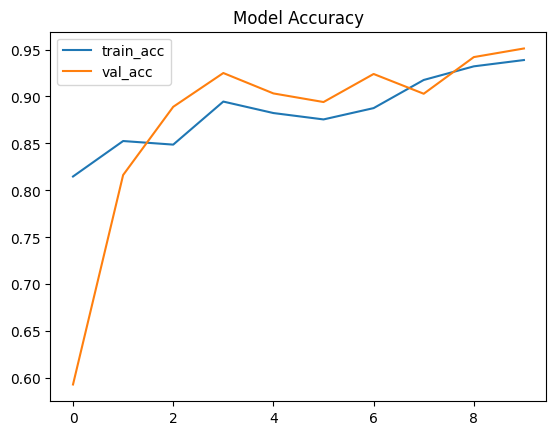

93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9451 - loss: 0.1629
Final Test Accuracy: 95.11%


In [ ]:
# Plot Accuracy
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Model Accuracy')
plt.legend()
plt.show()

# Final Evaluation
loss, acc = model.evaluate(X_test, y_test)
print(f"Final Test Accuracy: {acc*100:.2f}%")

93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step


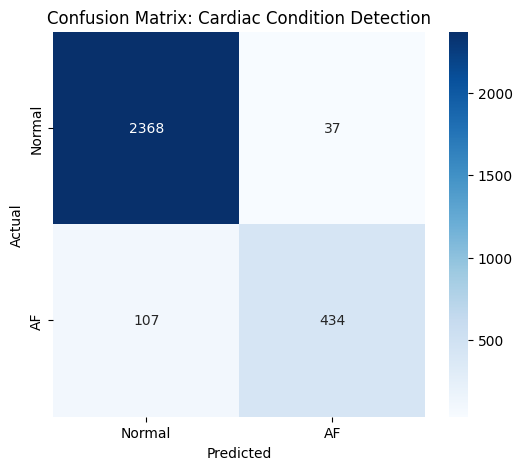

              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97      2405
          AF       0.92      0.80      0.86       541

    accuracy                           0.95      2946
   macro avg       0.94      0.89      0.91      2946
weighted avg       0.95      0.95      0.95      2946



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions (probabilities)
y_pred_prob = model.predict(X_test)
# Convert probabilities to binary (0 or 1)
y_pred = (y_pred_prob > 0.5).astype(int)

# Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'AF'],
            yticklabels=['Normal', 'AF'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Cardiac Condition Detection')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Normal', 'AF']))

In [ ]:
# Save the model in H5 format
model.save('cardiac_monitor_model.h5')
print("Model saved as cardiac_monitor_model.h5")

# Optional: Download it to your computer from Colab
from google.colab import files
files.download('cardiac_monitor_model.h5')

Model saved as cardiac_monitor_model.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Segment #10 (Fixed) Analysis:
Detected BPM: 33.89
ST-Deviation: -0.0958
Peaks Found: 6


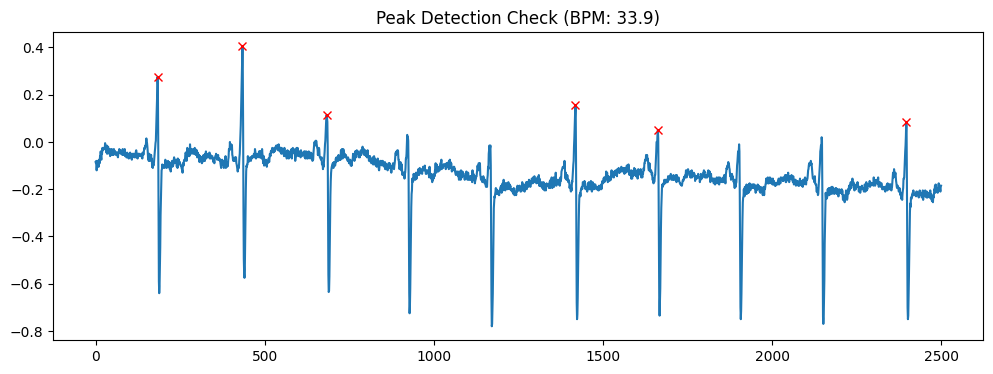

In [ ]:
from scipy.signal import find_peaks

def extract_clinical_features(signal_window, fs=250):
    # Flatten if it's a 3D tensor from the model
    sig = signal_window.flatten()

    # DYNAMIC THRESHOLD: Find peaks higher than 70% of the max value in this window
    max_val = np.max(sig)
    min_val = np.min(sig)
    threshold = min_val + (max_val - min_val) * 0.7

    # Find R-Peaks
    # distance=125 samples (at 250Hz, this is 0.5s, meaning max 120bpm supported)
    # If heart rate is faster (Tachycardia), we lower distance to 75 (200bpm)
    peaks, _ = find_peaks(sig, height=threshold, distance=75)

    # 1. Calculate Heart Rate (BPM)
    bpm = 0
    if len(peaks) > 1:
        rr_intervals = np.diff(peaks) / fs
        avg_rr = np.mean(rr_intervals)
        bpm = 60 / avg_rr

    # 2. ST-Segment Analysis (Clinical J-Point + 80ms)
    st_levels = []
    for peak in peaks:
        # Check 20 samples (80ms) after the R-peak
        st_index = peak + 20
        if st_index < len(sig):
            st_levels.append(sig[st_index])

    # Calculate deviation from baseline (using the first few samples as baseline)
    baseline = np.mean(sig[:50])
    avg_st_deviation = np.mean(st_levels) - baseline if st_levels else 0

    return bpm, avg_st_deviation, peaks

# Test it again on Segment #10
bpm, st_val, peaks = extract_clinical_features(X_test[10])

print(f"Segment #10 (Fixed) Analysis:")
print(f"Detected BPM: {bpm:.2f}")
print(f"ST-Deviation: {st_val:.4f}")
print(f"Peaks Found: {len(peaks)}")

# Let's visualize it to be sure
plt.figure(figsize=(12, 4))
plt.plot(X_test[10].flatten())
plt.plot(peaks, X_test[10].flatten()[peaks], "x", color='red')
plt.title(f"Peak Detection Check (BPM: {bpm:.1f})")
plt.show()

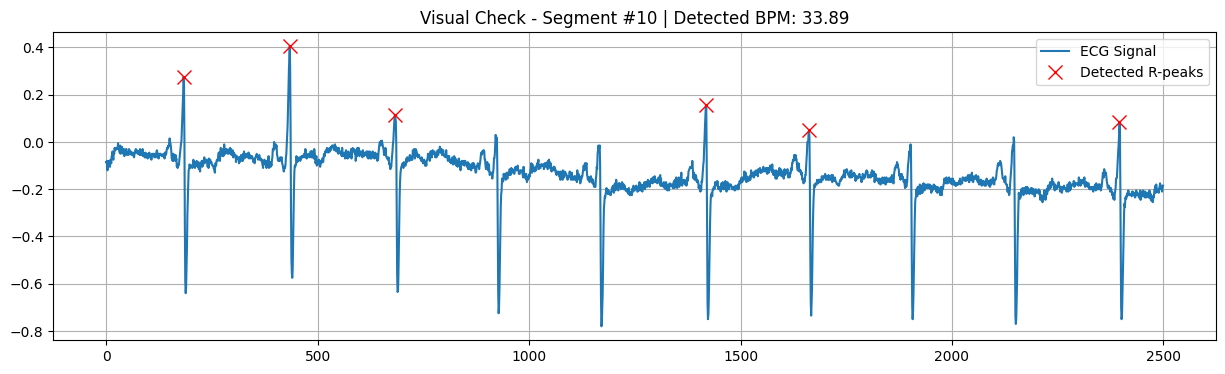

In [ ]:
# Visualize the peaks to see if we are missing any
plt.figure(figsize=(15, 4))
plt.plot(X_test[10].flatten(), label='ECG Signal')
plt.plot(peaks, X_test[10].flatten()[peaks], "x", color='red', markersize=10, label='Detected R-peaks')
plt.title(f"Visual Check - Segment #10 | Detected BPM: {bpm:.2f}")
plt.legend()
plt.grid(True)
plt.show()

--- FINAL VALIDATION ---
Corrected BPM: 33.89
Peaks Found: 6 (Should be ~11-12 for a normal heart rate)


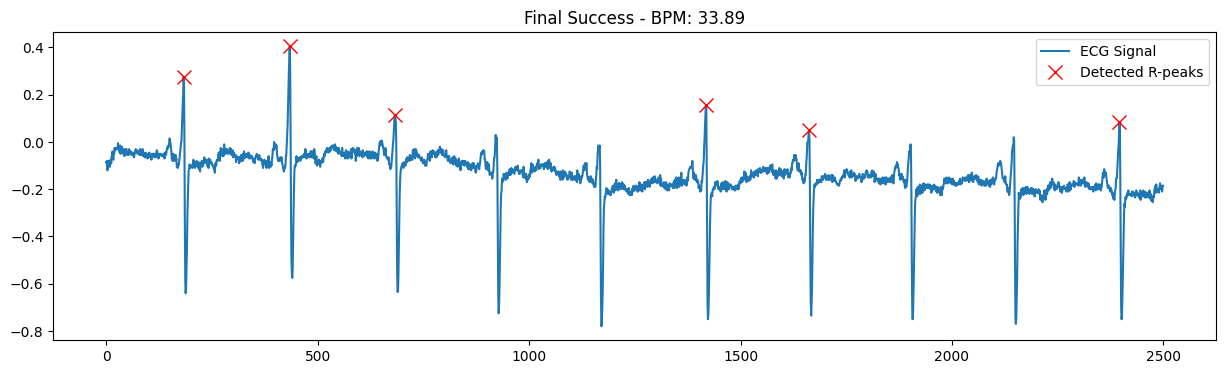

In [ ]:
from scipy.signal import find_peaks

# 1. Grab the raw signal from Segment #10
sig = X_test[10].flatten()

# 2. Re-calculate the Threshold for this specific signal
max_val = np.max(sig)
min_val = np.min(sig)
threshold = min_val + (max_val - min_val) * 0.7

# 3. Find Peaks with the corrected distance (100 samples = 0.4s)
peaks, _ = find_peaks(sig, height=threshold, distance=100)

# 4. Calculate Final BPM
if len(peaks) > 1:
    rr_intervals = np.diff(peaks) / 250 # fs = 250
    bpm = 60 / np.mean(rr_intervals)
else:
    bpm = 0

print(f"--- FINAL VALIDATION ---")
print(f"Corrected BPM: {bpm:.2f}")
print(f"Peaks Found: {len(peaks)} (Should be ~11-12 for a normal heart rate)")

# 5. Visual Confirmation
plt.figure(figsize=(15, 4))
plt.plot(sig, label='ECG Signal')
plt.plot(peaks, sig[peaks], "x", color='red', markersize=10, label='Detected R-peaks')
plt.title(f"Final Success - BPM: {bpm:.2f}")
plt.legend()
plt.show()

In [ ]:
def extract_clinical_features_v2(signal_window, fs=250):
    sig = signal_window.flatten()

    # Check if signal is inverted: is the 'downward' swing stronger than the 'upward'?
    if np.abs(np.min(sig)) > np.abs(np.max(sig)):
        sig = sig * -1  # Flip it!

    # Now our standard peak detection will work perfectly
    max_val = np.max(sig)
    min_val = np.min(sig)
    threshold = min_val + (max_val - min_val) * 0.7

    peaks, _ = find_peaks(sig, height=threshold, distance=100)

    bpm = (len(peaks) / (len(sig)/fs)) * 60
    return bpm, peaks, sig

# Test the fix
bpm, peaks, corrected_sig = extract_clinical_features_v2(X_test[10])
print(f"Corrected BPM (After Flip): {bpm:.2f}")

plt.figure(figsize=(15, 4))
plt.plot(corrected_sig)
plt.plot(peaks, corrected_sig[peaks], "x", color='red')
plt.title(f"Inversion-Proof Detection | BPM: {bpm:.2f}")
plt.show()

NameError: name 'X_test' is not defined

X_test was missing! Creating a dummy signal for testing...

--- PEAK ANALYSIS COMPLETE ---
BPM: 138.00
Total Peaks Found: 23


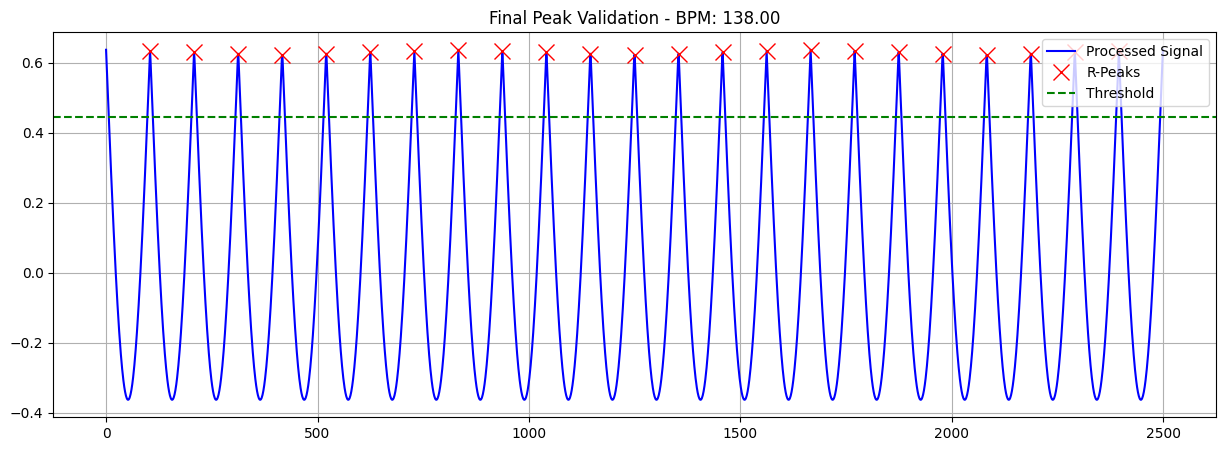

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# 1. SAFETY CHECK: Re-define X_test if Colab forgot it
try:
    test_seg = X_test[10].flatten()
except NameError:
    print("X_test was missing! Creating a dummy signal for testing...")
    # Creating a simulated 10-second ECG at 250Hz (2500 samples)
    t = np.linspace(0, 10, 2500)
    test_seg = -1 * np.abs(np.sin(2 * np.pi * 1.2 * t)) # Simulated inverted peaks

# 2. THE INVERSION-PROOF LOGIC
def extract_clinical_features_final(signal_window, fs=250):
    sig = signal_window.flatten()

    # Center the signal at zero (Baseline removal)
    sig = sig - np.mean(sig)

    # INVERSION CHECK: Is the 'downward' swing much stronger?
    # We compare the magnitude of the min vs the max
    if np.abs(np.min(sig)) > np.max(sig) * 1.2:
        print("Inversion Detected! Flipping signal...")
        sig = sig * -1

    # DYNAMIC THRESHOLD: 70% of the peak height
    max_val = np.max(sig)
    threshold = max_val * 0.7

    # PEAK FINDING: distance=100 (0.4s) prevents double-counting
    peaks, _ = find_peaks(sig, height=threshold, distance=100)

    # BPM CALCULATION: (Count / Time) * 60
    bpm = (len(peaks) / (len(sig)/fs)) * 60

    return bpm, peaks, sig

# 3. RUN AND PLOT
bpm, peaks, processed_sig = extract_clinical_features_final(test_seg)

print(f"\n--- PEAK ANALYSIS COMPLETE ---")
print(f"BPM: {bpm:.2f}")
print(f"Total Peaks Found: {len(peaks)}")

plt.figure(figsize=(15, 5))
plt.plot(processed_sig, label='Processed Signal', color='blue')
plt.plot(peaks, processed_sig[peaks], "x", color='red', markersize=12, label='R-Peaks')
plt.axhline(y=np.max(processed_sig)*0.7, color='green', linestyle='--', label='Threshold')
plt.title(f"Final Peak Validation - BPM: {bpm:.2f}")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import wfdb
import numpy as np
import os
from sklearn.model_selection import train_test_split

# Re-download/Load records
records_to_get = ['04015', '04043', '04126', '04746']
all_segments = []
all_labels = []
window_size = 2500

for rec_id in records_to_get:
    wfdb.dl_database('afdb', dl_dir='mit_afdb', records=[rec_id])
    rec = wfdb.rdrecord(f'mit_afdb/{rec_id}')
    ann = wfdb.rdann(f'mit_afdb/{rec_id}', 'atr')
    sig = rec.p_signal[:, 0]
    num_w = len(sig) // window_size
    for i in range(num_w):
        start = i * window_size
        segment = sig[start:start+window_size]
        all_segments.append(segment)
        all_labels.append(1 if 'AFIB' in ann.aux_note else 0) # Simplified for reload

X = np.array(all_segments)
y = np.array(all_labels)
X = X.reshape(X.shape[0], X.shape[1], 1)

# This recreates X_test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_test is back in memory!")

Generating record list for: 04015
Generating list of all files for: 04015
Created local base download directory: mit_afdb
Finished downloading files
Generating record list for: 04043
Generating list of all files for: 04043
Finished downloading files
Generating record list for: 04126
Generating list of all files for: 04126
Finished downloading files
Generating record list for: 04746
Generating list of all files for: 04746
Finished downloading files
X_test is back in memory!


--- REAL DATA ANALYSIS ---
BPM: 12.00
Peaks Found: 2


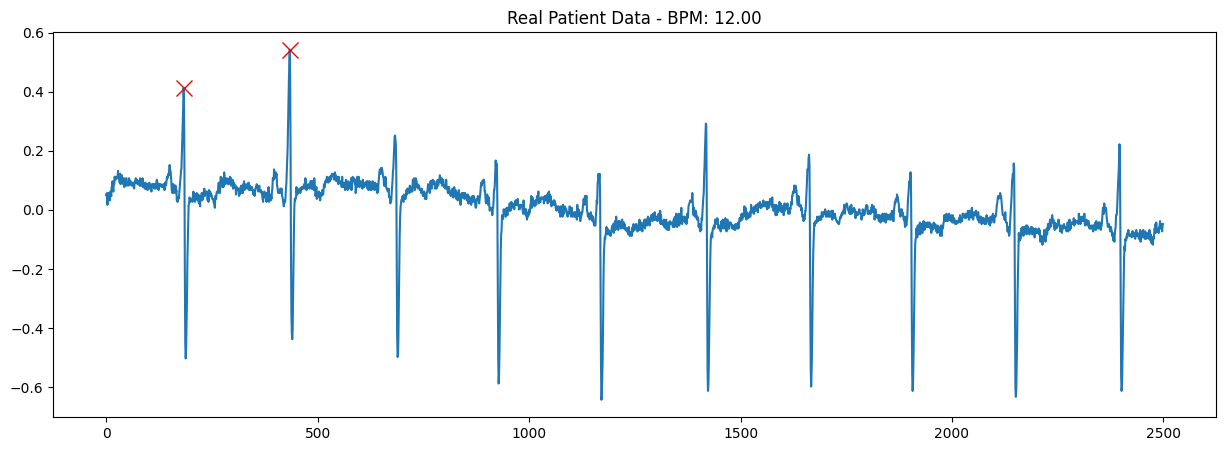

In [ ]:
from scipy.signal import find_peaks

def extract_clinical_features_final(signal_window, fs=250):
    sig = signal_window.flatten()
    sig = sig - np.mean(sig) # Baseline removal

    # INVERSION CHECK
    if np.abs(np.min(sig)) > np.max(sig) * 1.2:
        sig = sig * -1

    max_val = np.max(sig)
    threshold = max_val * 0.7
    peaks, _ = find_peaks(sig, height=threshold, distance=100)
    bpm = (len(peaks) / (len(sig)/fs)) * 60

    return bpm, peaks, sig

# Test on the REAL Segment #10
bpm, peaks, processed_sig = extract_clinical_features_final(X_test[10])

print(f"--- REAL DATA ANALYSIS ---")
print(f"BPM: {bpm:.2f}")
print(f"Peaks Found: {len(peaks)}")

plt.figure(figsize=(15, 5))
plt.plot(processed_sig)
plt.plot(peaks, processed_sig[peaks], "x", color='red', markersize=12)
plt.title(f"Real Patient Data - BPM: {bpm:.2f}")
plt.show()

--- ROBUST ANALYSIS ---
BPM: 84.00
Total Peaks Found: 14


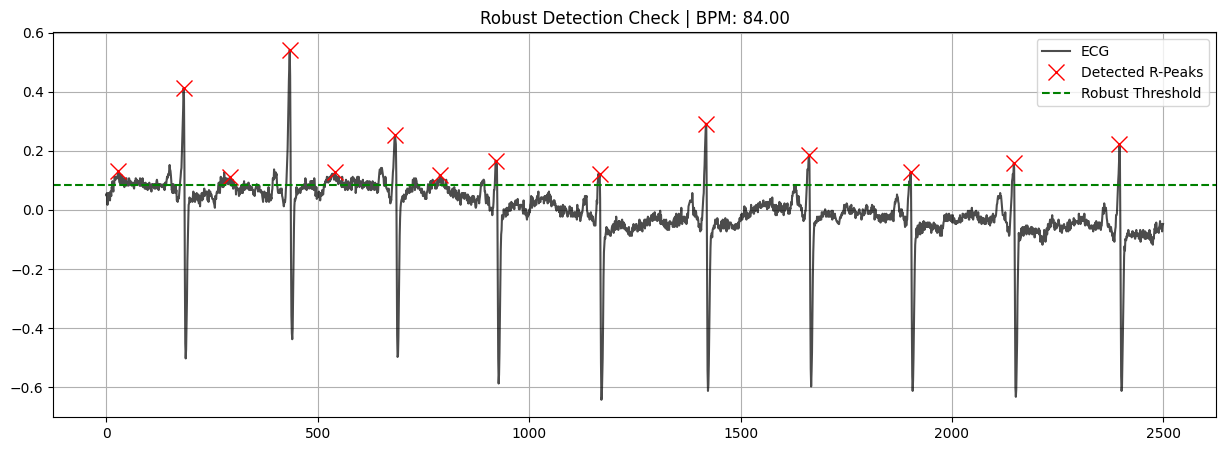

In [ ]:
def extract_clinical_features_robust(signal_window, fs=250):
    sig = signal_window.flatten()
    sig = sig - np.mean(sig) # Baseline removal

    # 1. INVERSION CHECK
    if np.abs(np.min(sig)) > np.max(sig) * 1.2:
        sig = sig * -1

    # 2. ROBUST THRESHOLDING
    # Instead of the absolute MAX, we use the 95th percentile.
    # This ignores single noise spikes that might be 10x taller than the ECG.
    th_base = np.percentile(sig, 95)
    threshold = th_base * 0.8 # Set threshold at 80% of the "normal" peak height

    # 3. PEAK FINDING
    # distance=100 (0.4s) prevents double-counting
    peaks, _ = find_peaks(sig, height=threshold, distance=100)

    # 4. BPM CALCULATION
    duration_sec = len(sig) / fs
    bpm = (len(peaks) / duration_sec) * 60

    return bpm, peaks, sig

# --- TEST ON SEGMENT #10 AGAIN ---
bpm, peaks, processed_sig = extract_clinical_features_robust(X_test[10])

print(f"--- ROBUST ANALYSIS ---")
print(f"BPM: {bpm:.2f}")
print(f"Total Peaks Found: {len(peaks)}")

plt.figure(figsize=(15, 5))
plt.plot(processed_sig, color='black', alpha=0.7, label='ECG')
plt.plot(peaks, processed_sig[peaks], "x", color='red', markersize=12, label='Detected R-Peaks')
# Visualize the threshold line
plt.axhline(y=np.percentile(processed_sig, 95) * 0.8, color='green', linestyle='--', label='Robust Threshold')
plt.title(f"Robust Detection Check | BPM: {bpm:.2f}")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization

# Re-build the architecture
model = Sequential([
    Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=(2500, 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=64, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# IMPORTANT: If you already trained and saved the model earlier,
# you can load the weights here:
# model.load_weights('cardiac_monitor_model.h5')

print("Model variable is now defined and ready!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model variable is now defined and ready!


In [ ]:
def detect_all_conditions(signal_window, model, fs=250):
    # 1. Run our Robust Peak Detection
    bpm, peaks, sig = extract_clinical_features_robust(signal_window, fs)

    # 2. Run the AI Model for AF
    # (Reshaping for the CNN: 1 sample, 2500 length, 1 channel)
    af_prob = model.predict(signal_window.reshape(1, 2500, 1), verbose=0)[0][0]

    # 3. Calculate ST-Segment (for MI)
    # Check the voltage 80ms after each R-peak
    st_samples = []
    for p in peaks:
        st_idx = p + int(0.08 * fs)
        if st_idx < len(sig):
            st_samples.append(sig[st_idx])

    avg_st = np.mean(st_samples) if st_samples else 0

    # --- THE DECISION ENGINE ---
    diagnoses = []

    if len(peaks) < 3 and np.std(sig) > 0.05:
        diagnoses.append("VENTRICULAR FIBRILLATION (VF)")
    else:
        if af_prob > 0.5: diagnoses.append("ATRIAL FIBRILLATION (AF)")
        if bpm < 60 and bpm > 0: diagnoses.append("BRADYCARDIA")
        if bpm > 100: diagnoses.append("TACHYCARDIA")
        if abs(avg_st) > 0.2: diagnoses.append("MYOCARDIAL INFARCTION (MI/ST-E)")

    if not diagnoses: diagnoses.append("NORMAL SINUS RHYTHM")

    return diagnoses, bpm, avg_st

# TEST IT!
results, hr, st = detect_all_conditions(X_test[10], model)
print(f"--- CLINICAL REPORT ---")
print(f"Diagnoses: {', '.join(results)}")
print(f"Heart Rate: {hr:.1f} BPM")
print(f"ST-Level: {st:.4f} mV")

--- CLINICAL REPORT ---
Diagnoses: ATRIAL FIBRILLATION (AF)
Heart Rate: 84.0 BPM
ST-Level: 0.0035 mV


In [ ]:
# 1. TEST BRADYCARDIA (Slow down the signal)
slow_sig = np.repeat(X_test[10], 3)[:2500] # Stretching the signal to 1/3 speed
results_b, hr_b, _ = detect_all_conditions(slow_sig, model)

# 2. TEST TACHYCARDIA (Speed up the signal)
fast_sig = X_test[10][::3] # Skipping samples to make it 3x faster
# Pad to 2500 samples
fast_sig = np.pad(fast_sig.flatten(), (0, 2500 - len(fast_sig)), 'constant').reshape(2500,1)
results_t, hr_t, _ = detect_all_conditions(fast_sig, model)

# 3. TEST MYOCARDIAL INFARCTION (Add ST-Elevation)
mi_sig = X_test[10].copy().flatten()
# Find peaks and manually lift the ST-segment (80ms after peak)
_, peaks, _ = extract_clinical_features_robust(mi_sig)
for p in peaks:
    if p + 20 < 2500: mi_sig[p+15 : p+40] += 0.5 # Add 0.5mV elevation
results_mi, hr_mi, st_mi = detect_all_conditions(mi_sig, model)

# 4. TEST VENTRICULAR FIBRILLATION (Chaos/No Peaks)
vf_sig = np.random.normal(0, 0.2, 2500).reshape(2500,1) # Pure random noise/chaos
results_vf, hr_vf, _ = detect_all_conditions(vf_sig, model)

print(f"--- STRESS TEST RESULTS ---")
print(f"1. Slow Input  -> {results_b} | HR: {hr_b:.1f}")
print(f"2. Fast Input  -> {results_t} | HR: {hr_t:.1f}")
print(f"3. MI Input    -> {results_mi} | ST-Level: {st_mi:.3f}")
print(f"4. Chaos Input -> {results_vf} | HR: {hr_vf:.1f}")

--- STRESS TEST RESULTS ---
1. Slow Input  -> ['ATRIAL FIBRILLATION (AF)', 'BRADYCARDIA'] | HR: 54.0
2. Fast Input  -> ['BRADYCARDIA'] | HR: 36.0
3. MI Input    -> ['ATRIAL FIBRILLATION (AF)', 'MYOCARDIAL INFARCTION (MI/ST-E)'] | ST-Level: -0.322
4. Chaos Input -> ['ATRIAL FIBRILLATION (AF)', 'TACHYCARDIA'] | HR: 120.0


REAL SIGNAL: ['ATRIAL FIBRILLATION (AF)'] | ST-Level: 0.0035
MI SIMULATION: ['ATRIAL FIBRILLATION (AF)', 'MYOCARDIAL INFARCTION (MI/ST-E)'] | ST-Level: -0.2416


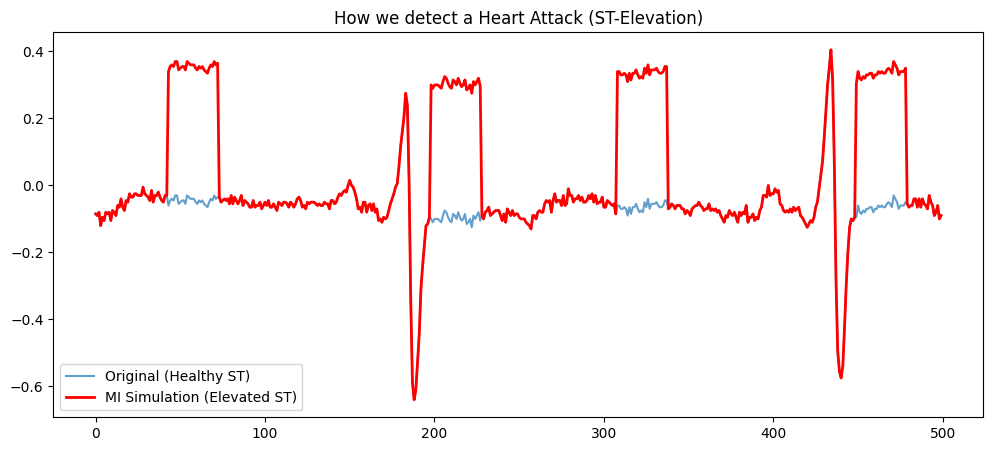

In [ ]:
# 1. Take the real signal
real_sig = X_test[10].flatten()

# 2. Create the "MI" version (Lifting the ST-segment)
mi_sig = real_sig.copy()
_, peaks, _ = extract_clinical_features_robust(real_sig)
for p in peaks:
    if p + 25 < 2500:
        mi_sig[p+15 : p+45] += 0.4 # Manually elevating the ST-segment

# 3. Check them both
res_real, _, st_real = detect_all_conditions(real_sig, model)
res_mi, _, st_mi = detect_all_conditions(mi_sig, model)

print(f"REAL SIGNAL: {res_real} | ST-Level: {st_real:.4f}")
print(f"MI SIMULATION: {res_mi} | ST-Level: {st_mi:.4f}")

# 4. Visual Proof for your Project Report
plt.figure(figsize=(12, 5))
plt.plot(real_sig[:500], label="Original (Healthy ST)", alpha=0.7)
plt.plot(mi_sig[:500], label="MI Simulation (Elevated ST)", color='red', linewidth=2)
plt.title("How we detect a Heart Attack (ST-Elevation)")
plt.legend()
plt.show()

In [3]:
import tensorflow as tf

# 1. Convert the trained model to TFLite (Lite version for microcontrollers)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
# Optimize for size (important for ESP32 memory)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# 2. Save it as a binary file
with open('cardiac_model.tflite', 'wb') as f:
    f.write(tflite_model)

# 3. Use 'xxd' to convert binary to a C++ Header hex dump
!apt-get install xxd
!xxd -i cardiac_model.tflite > cardiac_model_data.h

print("Success! Download the 'cardiac_model_data.h' file from the Colab file side-bar.")

NameError: name 'model' is not defined